# Voting by Expected Free Energy minimization

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

plt.rcParams["figure.constrained_layout.use"] = True

We use the cross-entropy between the preference and the political offer to measure the political offer fit to a given citizen. As per the definition of cross-entropy, $H(p,q)$ is *the expected surprise of the scorer q when the world is generated by p*. The first argument is the distribution reality is drawn from; the second is the distribution used to judge it.

In our simulation, we therefore use $H(o, p)$, with $o$ the political offer and $p$ the preference, as a measure of the expected citizen's dissatisfaction if reality ends up being generated by $o$.

The cross-entropy between two univariate Gaussians $p=\mathcal{N}(\mu_1,\sigma_1)$ and $q=\mathcal{N}(\mu_2,\sigma_2)$ is given by:

$$H(p,q) = -\mathbb{E}_p[\log q(x)] = \tfrac{1}{2}\log(2\pi\sigma_2^2) + \dfrac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2}$$

In [2]:
def cross_entropy_gaussian(mu1, sigma1, mu2, sigma2):
    """Compute the cross-entropy between two univariate Gaussian distributions."""
    return 0.5 * np.log(2 * np.pi * sigma2**2) + (sigma1**2 + (mu1 - mu2) ** 2) / (
        2 * sigma2**2
    )

We express dissatisfaction as the mismatch between the agent's beliefs about the current state of the environment and its preference, such as $H(b, p)$, with $b$ the current belief and $p$ the preference.

In [3]:
import ipywidgets as widgets
from IPython.display import display

color_pref = "#761e58"  # preference (what the voter wants)
color_offer = "#234c80"  # political offer (what the candidate proposes)
color_belief = "#d95f02"  # current belief of the agent

_x = np.linspace(-10.0, 10.0, 500)


def plot_belief_offer_preference(
    mu_pref, sigma_pref, mu_belief, sigma_belief, mu_offer, sigma_offer
):
    """Draw the three Gaussians and the offer's net dissatisfaction gain."""
    dists = {
        "pref": (mu_pref, sigma_pref),
        "belief": (mu_belief, sigma_belief),
        "offer": (mu_offer, sigma_offer),
    }

    fig, (ax_dist, ax_bar) = plt.subplots(
        ncols=2, figsize=(9, 4), gridspec_kw={"width_ratios": [3, 1]}
    )

    # --- left: the three distributions ---
    for key, color, label in [
        ("pref", color_pref, "Preference"),
        ("belief", color_belief, "Belief"),
        ("offer", color_offer, "Political offer"),
    ]:
        mu, sigma = dists[key]
        y = norm.pdf(_x, mu, sigma)
        ax_dist.fill_between(_x, y, alpha=0.4, color=color, linewidth=0.0)
        ax_dist.plot(_x, y, color="k", linewidth=0.6, label=label)

    ax_dist.set(xlim=(_x.min(), _x.max()), xlabel="Political position")
    ax_dist.yaxis.set_visible(False)
    ax_dist.spines["left"].set_visible(False)
    ax_dist.legend(frameon=False, loc="upper right")

    # --- right: dissatisfaction minus preference fit, H(b, p) - H(o, p) ---
    # Positive => the current belief is more dissatisfying than the offer,
    # i.e. switching to the offer reduces dissatisfaction (the offer is favourable).
    ce_belief = cross_entropy_gaussian(*dists["belief"], *dists["pref"])  # H(b, p)
    ce_offer = cross_entropy_gaussian(*dists["offer"], *dists["pref"])  # H(o, p)
    delta = ce_belief - ce_offer

    bars = ax_bar.bar(
        0,
        delta,
        width=0.5,
        color="#55a868" if delta >= 0 else "#c44e52",
        edgecolor="black",
    )
    ax_bar.bar_label(bars, fmt="%.2f", padding=2)
    ax_bar.axhline(0, color="k", linewidth=0.6)
    ax_bar.set_xticks([0])
    ax_bar.set_xticklabels([r"$H(b, p) - H(o, p)$"])
    ax_bar.set_xlim(-1, 1)
    ax_bar.set_ylabel("nats")

    sns.despine(ax=ax_dist, left=True)
    sns.despine(ax=ax_bar)
    plt.show()


_sliders_b = {
    "mu_pref": widgets.FloatSlider(
        value=0.0, min=-6, max=6, step=0.1, description="μ pref"
    ),
    "sigma_pref": widgets.FloatSlider(
        value=1.0, min=0.2, max=4, step=0.1, description="σ pref"
    ),
    "mu_belief": widgets.FloatSlider(
        value=-1.0, min=-6, max=6, step=0.1, description="μ belief"
    ),
    "sigma_belief": widgets.FloatSlider(
        value=1.2, min=0.2, max=4, step=0.1, description="σ belief"
    ),
    "mu_offer": widgets.FloatSlider(
        value=2.0, min=-6, max=6, step=0.1, description="μ offer"
    ),
    "sigma_offer": widgets.FloatSlider(
        value=1.5, min=0.2, max=4, step=0.1, description="σ offer"
    ),
}

_out_b = widgets.interactive_output(plot_belief_offer_preference, _sliders_b)
_controls_b = widgets.VBox(
    [
        widgets.HTML("<b>Preference</b> (what the voter wants)"),
        _sliders_b["mu_pref"],
        _sliders_b["sigma_pref"],
        widgets.HTML("<b>Belief</b> (what the agent currently believes)"),
        _sliders_b["mu_belief"],
        _sliders_b["sigma_belief"],
        widgets.HTML("<b>Political offer</b> (what the candidate proposes)"),
        _sliders_b["mu_offer"],
        _sliders_b["sigma_offer"],
    ]
)
display(widgets.HBox([_controls_b, _out_b]))

/var/folders/kb/2ftph0z55ll1n6b3wfqrtwmr0000gn/T/ipykernel_85570/1845582612.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


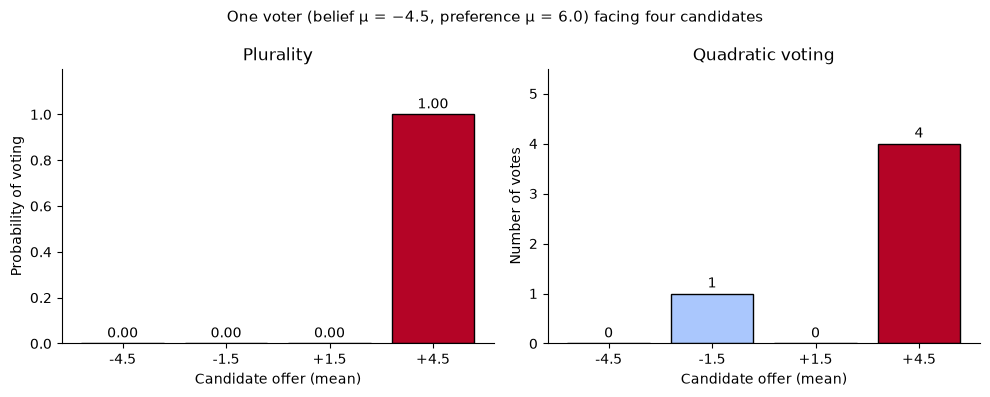

In [4]:
import jax
import jax.numpy as jnp

from eci.decision import response_function_cross_entropy
from eci.voting import _vote_plurality, _vote_quadratic

# --- Scenario: one representative voter facing four candidates ---
# precision = 1 / sigma**2 = 1.0 everywhere (sigma = 1).
candidate_means = [-4.5, -1.5, 1.5, 4.5]
data = {
    "beliefs": {"mean": jnp.array([[-4.5]]), "precision": jnp.array([[1.0]])},
    "preferences": {"mean": jnp.array([[6.0]]), "precision": jnp.array([[1.0]])},
    "candidates": {
        "mean": jnp.array([[m] for m in candidate_means]),
        "precision": jnp.ones((len(candidate_means), 1)),
    },
}
key = jax.random.PRNGKey(0)

# Decision relies only on the cross-entropy score H(candidate, preference) and softmax
# (no KL). The belief-vs-preference term H(b, p) is constant across candidates, so it
# cancels in the softmax and does not affect the vote.
response_function = response_function_cross_entropy
plurality = _vote_plurality(data, response_function, key)
quadratic = _vote_quadratic(data, response_function, key)  # budget=99, num_votes=5

vote_prob = np.asarray(plurality["softmax"][0])  # P(vote) per candidate
qv_votes = np.asarray(quadratic["votes_per_candidate"])  # QV votes per candidate

# --- Figure: voting probability (plurality) vs. allocated votes (quadratic) ---
labels = [f"{m:+.1f}" for m in candidate_means]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(candidate_means)))

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

bars1 = ax1.bar(labels, vote_prob, color=colors, edgecolor="black")
ax1.bar_label(bars1, fmt="%.2f", padding=2)
ax1.set(
    title="Plurality",
    xlabel="Candidate offer (mean)",
    ylabel="Probability of voting",
    ylim=(0, vote_prob.max() * 1.2),
)

bars2 = ax2.bar(labels, qv_votes, color=colors, edgecolor="black")
ax2.bar_label(bars2, fmt="%d", padding=2)
ax2.set(
    title="Quadratic voting",
    xlabel="Candidate offer (mean)",
    ylabel="Number of votes",
    ylim=(0, qv_votes.max() * 1.25 + 0.5),
)

fig.suptitle(
    "One voter (belief μ = −4.5, preference μ = 6.0) facing four candidates",
    fontsize=11,
)
sns.despine()
plt.tight_layout()
plt.show()

In this model, we let the belief and the dissatisfaction **both** shape the decision in a principled way; the belief has to enter the *generative model* of what each vote actually produces, not just sit beside it.

### The idea: vote for the world you expect, not the offer you see

Casting a vote is an **action**. Its consequence is not the candidate's manifesto in the abstract, but the **state of the world the agent expects if that candidate wins**. So for every candidate, we first form an *expected future belief* by treating the candidate's political offer as evidence that moves the current belief using a Bayesian update:

$$
\pi_{\text{fut}} = \pi_b + \pi_c, \qquad
\mu_{\text{fut}} = \frac{\mu_b\,\pi_b + \mu_c\,\pi_c}{\pi_b + \pi_c}.
$$

Precisions add (combining two sources makes the agent more certain), and the mean is pulled from the current belief toward the offer by an amount set by their relative precision. A *committed* candidate (high $\pi_c$) drags the world close to its offer; a *vague* one barely moves it. This is the step that makes the belief matter for the **ranking**: the value of an offer is filtered through where the agent currently stands.

### The objective: Expected Free Energy

The agent then judges that expected future world against its preference $P$ using
the cross-entropy "dissatisfaction", but applied to the expected dissatisfaction under the updated belief $q_{\text{fut}}$ rather than to the raw offer. This quantity is the **Expected Free Energy** of the vote, and it splits into two interpretable terms:

$$
G(c) \;=\; H\!\big(q^{c}_{\text{fut}},\, P\big)
\;=\; \underbrace{D_{KL}\!\big(q^{c}_{\text{fut}} \,\|\, P\big)}_{\textbf{risk}}
\;+\; \underbrace{H\!\big(q^{c}_{\text{fut}}\big)}_{\textbf{ambiguity}}.
$$

- **Risk**: how far the *expected outcome* sits from what the agent wants. This is the goal-directed, pragmatic term.
- **Ambiguity**: the residual uncertainty (entropy) of that expected world. All else equal, the agent prefers outcomes it can pin down.

A lower $G$ is better, and it can be read under three equivalent frameworks, which is why it is the principled choice:

1. **Bayesian decision theory** — $-G(c) = \mathbb{E}_{x\sim q^{c}_{\text{fut}}}[\log P(x)]$ is the *expected log-preference* of the world the vote produces, i.e., expected utility with a log-loss utility.
2. **Active inference** — $G$ is literally the Expected Free Energy; agents are posited to act to minimize it.
3. **Information theory** — it is the cross-entropy dissatisfaction of this section, evaluated on the realized future instead of on the platform.

### The decision rule and its parameters

Votes follow a **precision-weighted softmax** of the negative Expected Free Energy:

$$
P(\text{vote}=c) \;\propto\; \exp\!\big(-\gamma\, G(c)\big).
$$

- **$\gamma$ (action precision)** is the *principled* temperature. Large $\gamma$ → the agent commits sharply to the lowest-EFE candidate; $\gamma \to 0$ → an indifferent, near-uniform vote.

### Reading the figure below

The left panel decomposes $G(c)$ into risk and ambiguity for our running scenario. Because every candidate here shares the same precision, the **ambiguity term is identical** across candidates (the thin top band), so in this particular setup the
*ranking* is driven entirely by risk. Ambiguity only changes *which* candidate wins once candidates differ in how committed (precise) they are. The right panel sweeps the action precision $\gamma$: the very same EFE scores yield
anything from a hesitant, graded vote (small $\gamma$) to an almost deterministic one (large $\gamma$), without ever touching the ranking.

/var/folders/kb/2ftph0z55ll1n6b3wfqrtwmr0000gn/T/ipykernel_85570/1224125724.py:87: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


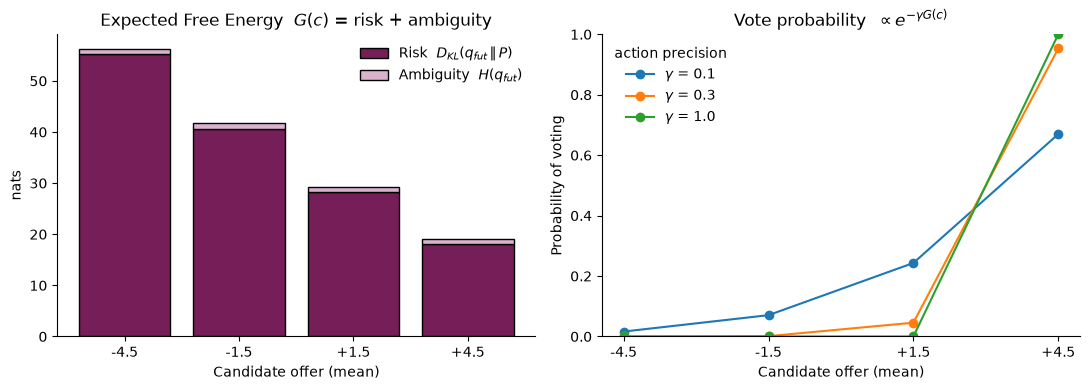

In [5]:
from functools import partial

from eci.decision import _get_expected_free_energy, response_function_efe
from eci.decision.utilities import _fuse_belief_candidate
from eci.utils import kl_divergence
from eci.voting import _vote_plurality

# Same scenario as above: one voter, four candidates, unit precision.
candidate_means = [-4.5, -1.5, 1.5, 4.5]
data = {
    "beliefs": {"mean": jnp.array([[-4.5]]), "precision": jnp.array([[1.0]])},
    "preferences": {"mean": jnp.array([[6.0]]), "precision": jnp.array([[1.0]])},
    "candidates": {
        "mean": jnp.array([[m] for m in candidate_means]),
        "precision": jnp.ones((len(candidate_means), 1)),
    },
}
key = jax.random.PRNGKey(0)

# Decompose the Expected Free Energy of each candidate into risk + ambiguity.
future_mean, future_prec = _fuse_belief_candidate(
    data["beliefs"]["mean"],
    data["beliefs"]["precision"],
    data["candidates"]["mean"],
    data["candidates"]["precision"],
)
risk = np.asarray(
    jnp.sum(
        kl_divergence(
            future_mean,
            future_prec,
            data["preferences"]["mean"][:, None, :],
            data["preferences"]["precision"][:, None, :],
        ),
        axis=-1,
    )[0]
)
free_energy = np.asarray(
    _get_expected_free_energy(
        data["beliefs"]["mean"],
        data["beliefs"]["precision"],
        data["preferences"]["mean"],
        data["preferences"]["precision"],
        data["candidates"]["mean"],
        data["candidates"]["precision"],
    )[0]
)
ambiguity = free_energy - risk

labels = [f"{m:+.1f}" for m in candidate_means]

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(11, 4))

# --- left: EFE decomposition G(c) = risk + ambiguity ---
risk_label = r"Risk  $D_{KL}(q_{fut}\,\|\,P)$"
ambiguity_label = r"Ambiguity  $H(q_{fut})$"
ax1.bar(labels, risk, color="#761e58", edgecolor="black", label=risk_label)
ax1.bar(
    labels,
    ambiguity,
    bottom=risk,
    color="#d9b3cc",
    edgecolor="black",
    label=ambiguity_label,
)
ax1.set(
    title="Expected Free Energy  $G(c)$ = risk + ambiguity",
    xlabel="Candidate offer (mean)",
    ylabel="nats",
)
ax1.legend(frameon=False)

# --- right: vote probability as the action precision gamma increases ---
for gamma in [0.1, 0.3, 1.0]:
    rf = partial(response_function_efe, gamma=gamma)
    probs = np.asarray(_vote_plurality(data, rf, key)["softmax"][0])
    ax2.plot(labels, probs, marker="o", label=rf"$\gamma$ = {gamma}")
ax2.set(
    title=r"Vote probability  $\propto e^{-\gamma G(c)}$",
    xlabel="Candidate offer (mean)",
    ylabel="Probability of voting",
    ylim=(0, 1),
)
ax2.legend(frameon=False, title="action precision")

sns.despine()
plt.tight_layout()
plt.show()

### How the belief changes the vote: far vs. close to the preference

The EFE vote fuses the agent's belief with each candidate's offer, then scores the
fused world against the preference — so *where the belief sits* changes which
candidate minimises EFE. Below we show the same pipeline for a belief **far from** the
preference and a belief **close to** it (preference fixed at $\mu = +6$; four
candidates at $\pm1.5, \pm4.5$ with increasing precision; $\gamma = 0.3$). Each figure shows the **belief** (grey) and **preference** (green) with the four
candidates' **updated beliefs** as dashed blue→red curves (left), the risk + ambiguity
decomposition of $G$ (middle), and the resulting vote (right).

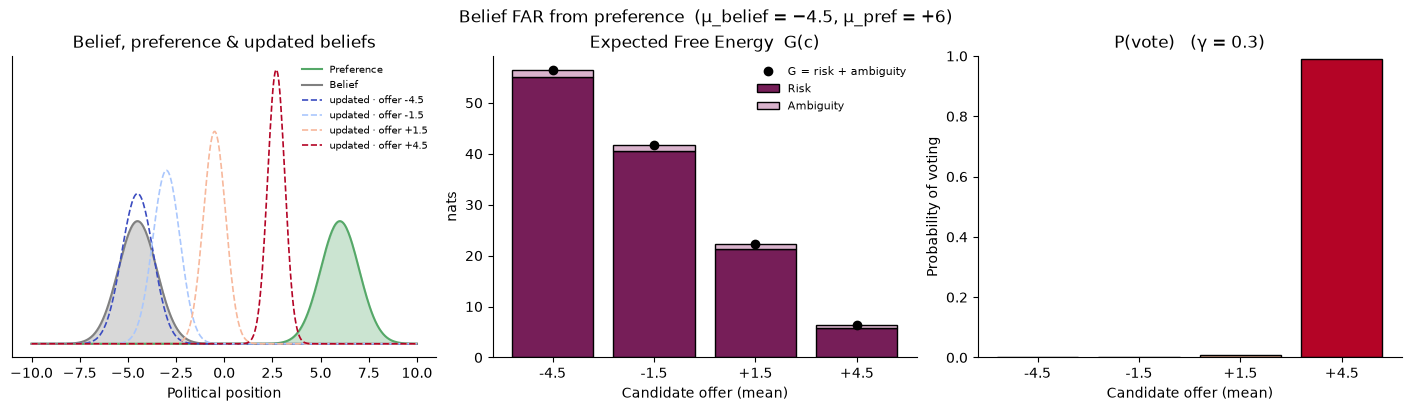

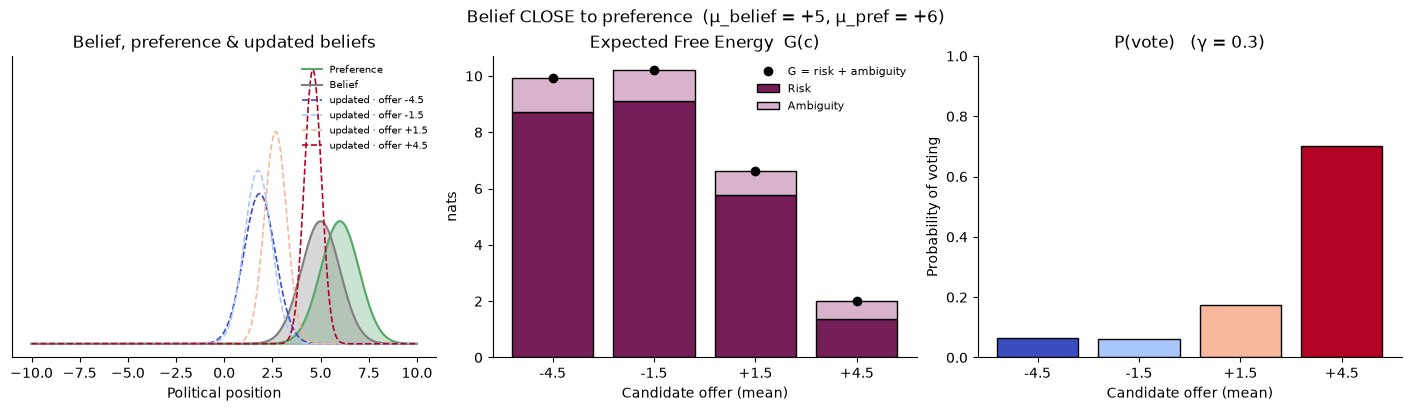

In [6]:
# Four fixed candidates with *differing* precision, so the ambiguity term
# varies across candidates (left = vague, right = committed).
candidate_means_efe = np.array([-4.5, -1.5, 1.5, 4.5])
candidate_prec_efe = np.array([0.5, 1.0, 2.0, 4.0])
_cand_colors = plt.cm.coolwarm(np.linspace(0, 1, len(candidate_means_efe)))
_efe_labels = [f"{m:+.1f}" for m in candidate_means_efe]


def plot_efe(mu_belief, sigma_belief, mu_pref, sigma_pref, gamma, title=""):
    """Plot the EFE vote: fusion -> risk + ambiguity -> softmax over candidates."""
    b_mean = jnp.array([[mu_belief]])
    b_prec = jnp.array([[1.0 / sigma_belief**2]])
    p_mean = jnp.array([[mu_pref]])
    p_prec = jnp.array([[1.0 / sigma_pref**2]])
    c_mean = jnp.array(candidate_means_efe)[:, None]
    c_prec = jnp.array(candidate_prec_efe)[:, None]

    # Fuse belief with each candidate, then decompose G = risk + ambiguity.
    future_mean, future_prec = _fuse_belief_candidate(b_mean, b_prec, c_mean, c_prec)
    risk = np.asarray(
        jnp.sum(
            kl_divergence(
                future_mean, future_prec, p_mean[:, None, :], p_prec[:, None, :]
            ),
            axis=-1,
        )[0]
    )

    g_total = np.asarray(
        _get_expected_free_energy(b_mean, b_prec, p_mean, p_prec, c_mean, c_prec)[0]
    )
    ambiguity = g_total - risk
    logits = -gamma * g_total
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()

    fig, (ax_d, ax_g, ax_p) = plt.subplots(ncols=3, figsize=(14, 4))
    xx = np.linspace(-10, 10, 400)

    # --- panel 1: belief (grey) + preference (green), and the four per-offer
    # updated beliefs (fused futures) as dashed blue->red curves ---
    ax_d.fill_between(xx, norm.pdf(xx, mu_pref, sigma_pref), alpha=0.3, color="#55a868")
    ax_d.plot(
        xx,
        norm.pdf(xx, mu_pref, sigma_pref),
        color="#55a868",
        lw=1.5,
        label="Preference",
    )
    ax_d.fill_between(xx, norm.pdf(xx, mu_belief, sigma_belief), alpha=0.3, color="0.5")
    ax_d.plot(
        xx,
        norm.pdf(xx, mu_belief, sigma_belief),
        color="0.5",
        lw=1.5,
        label="Belief",
    )
    for i, m in enumerate(candidate_means_efe):
        f_sd = 1.0 / np.sqrt(float(future_prec[0, i, 0]))
        ax_d.plot(
            xx,
            norm.pdf(xx, float(future_mean[0, i, 0]), f_sd),
            color=_cand_colors[i],
            lw=1.2,
            ls="--",
            label=f"updated · offer {m:+.1f}",
        )
    ax_d.set(
        title="Belief, preference & updated beliefs",
        xlabel="Political position",
    )
    ax_d.yaxis.set_visible(False)
    ax_d.spines["left"].set_visible(False)
    ax_d.legend(frameon=False, loc="upper right", fontsize=7)

    # --- panel 2: EFE decomposition into risk + ambiguity ---
    ax_g.bar(_efe_labels, risk, color="#761e58", edgecolor="black", label="Risk")
    ax_g.bar(
        _efe_labels,
        ambiguity,
        bottom=risk,
        color="#d9b3cc",
        edgecolor="black",
        label="Ambiguity",
    )
    ax_g.plot(_efe_labels, g_total, "ko", label="G = risk + ambiguity")
    ax_g.set(
        title="Expected Free Energy  G(c)",
        xlabel="Candidate offer (mean)",
        ylabel="nats",
    )
    ax_g.legend(frameon=False, fontsize=8)

    # --- panel 3: resulting vote probabilities ---
    ax_p.bar(_efe_labels, probs, color=_cand_colors, edgecolor="black")
    ax_p.set(
        title=f"P(vote)   (γ = {gamma:.1f})",
        xlabel="Candidate offer (mean)",
        ylabel="Probability of voting",
        ylim=(0, 1),
    )

    if title:
        fig.suptitle(title)
    sns.despine()


# Two contrasting cases (preference fixed at +6), replacing the interactive sliders.
plot_efe(
    mu_belief=-4.5,
    sigma_belief=1.0,
    mu_pref=6.0,
    sigma_pref=1.0,
    gamma=0.3,
    title="Belief FAR from preference  (μ_belief = −4.5, μ_pref = +6)",
)
plt.savefig("efe_far.png")
plot_efe(
    mu_belief=5.0,
    sigma_belief=1.0,
    mu_pref=6.0,
    sigma_pref=1.0,
    gamma=0.3,
    title="Belief CLOSE to preference  (μ_belief = +5, μ_pref = +6)",
)
plt.savefig("efe_close.png")